# Учимся работе с данными - от загрузки до моделирования

## Разведочный анализ данных

In [654]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [655]:
allow_corr_max = 0.85

In [656]:
# для того, чтобы обработка не терялась в коде
# код выносим к загрузке данных, вызывать будем уже по месту

# прежде чем работать с полями, нужно привести их к численному виду
# неинформативные поля просто удаляем
def columns_view_prepare(dataset):
    # удаляем неинформативные поля "id" и "Unnamed: 32"
    dataset.drop(["id", "Unnamed: 32"], axis="columns", inplace=True)
    # заменяем диагноз
    replace_dict = {"M" : 0, "B" : 1}
    dataset["diagnosis"] = dataset["diagnosis"].map(replace_dict)

# для обучения так же удаляем сильно коррелирующие поля
# Признаки с высокой корреляцией между собой,
# ожидаемо имеют схожую корреляцию с целевой переменной
# (разница корреляций в сотых долях, иногда в тысячных).
# Поэтому логично удалять не по корреляции с целевой переменной,
# а по различимости признака (например, среднее должно максимально отличаться).
def columns_learn_prepare(dataset, corr_coll, diff_coll):
    tangle_coll = corr_coll[corr_coll["relative_corr"] > allow_corr_max]
    tangle_coll_iter = tangle_coll.iterrows()
    remove_field_coll = []
    for corr_row in tangle_coll_iter:
        row_field_name = corr_row[1]["row"]
        diff_field_row = diff_coll["ratio"].loc[row_field_name]
        col_field_name = corr_row[1]["col"]
        diff_field_col = diff_coll["ratio"].loc[col_field_name]
        remove_field_coll.append(
            row_field_name if diff_field_row > diff_field_col else col_field_name)

    dataset.drop(remove_field_coll, axis="columns", inplace=True)


In [657]:
dataset_hosp = pd.read_csv("HW9(lesson37)_data.csv")

dataset_hosp.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [658]:
dataset_hosp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [659]:
dataset_hosp.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [660]:
# прежде чем работать с полями, нужно привести их к численному виду
# неинформативные поля просто удаляем
columns_view_prepare(dataset_hosp)
dataset_hosp.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [661]:
# готовим матрицу различимости параметров
# (параметры хорошо различимы если среднее у диагнозов сильно отличается)
diff_field = dataset_hosp.groupby("diagnosis").median().T
diff_field.rename({0: "median 0", 1: "median 1"}, axis = "columns", inplace = True)
diff_field["diff"] = diff_field.diff(axis = "columns").abs()["median 1"]
diff_field["ratio"]= diff_field["median 0"] / diff_field["median 1"]
# сортируем в обратном порядке, т.к. чем больше отличаются, тем лучше
diff_field.sort_values(by="ratio", inplace=True, ascending = False)

diff_field.head()

diagnosis,median 0,median 1,diff,ratio
concavity_mean,0.15135,0.03709,0.11426,4.080615
concave points_mean,0.08628,0.02344,0.06284,3.680887
area_se,58.45500,19.63000,38.82500,2.977840
concavity_worst,0.40490,0.14120,0.26370,2.867564
concave points_worst,0.18200,0.07431,0.10769,2.449199


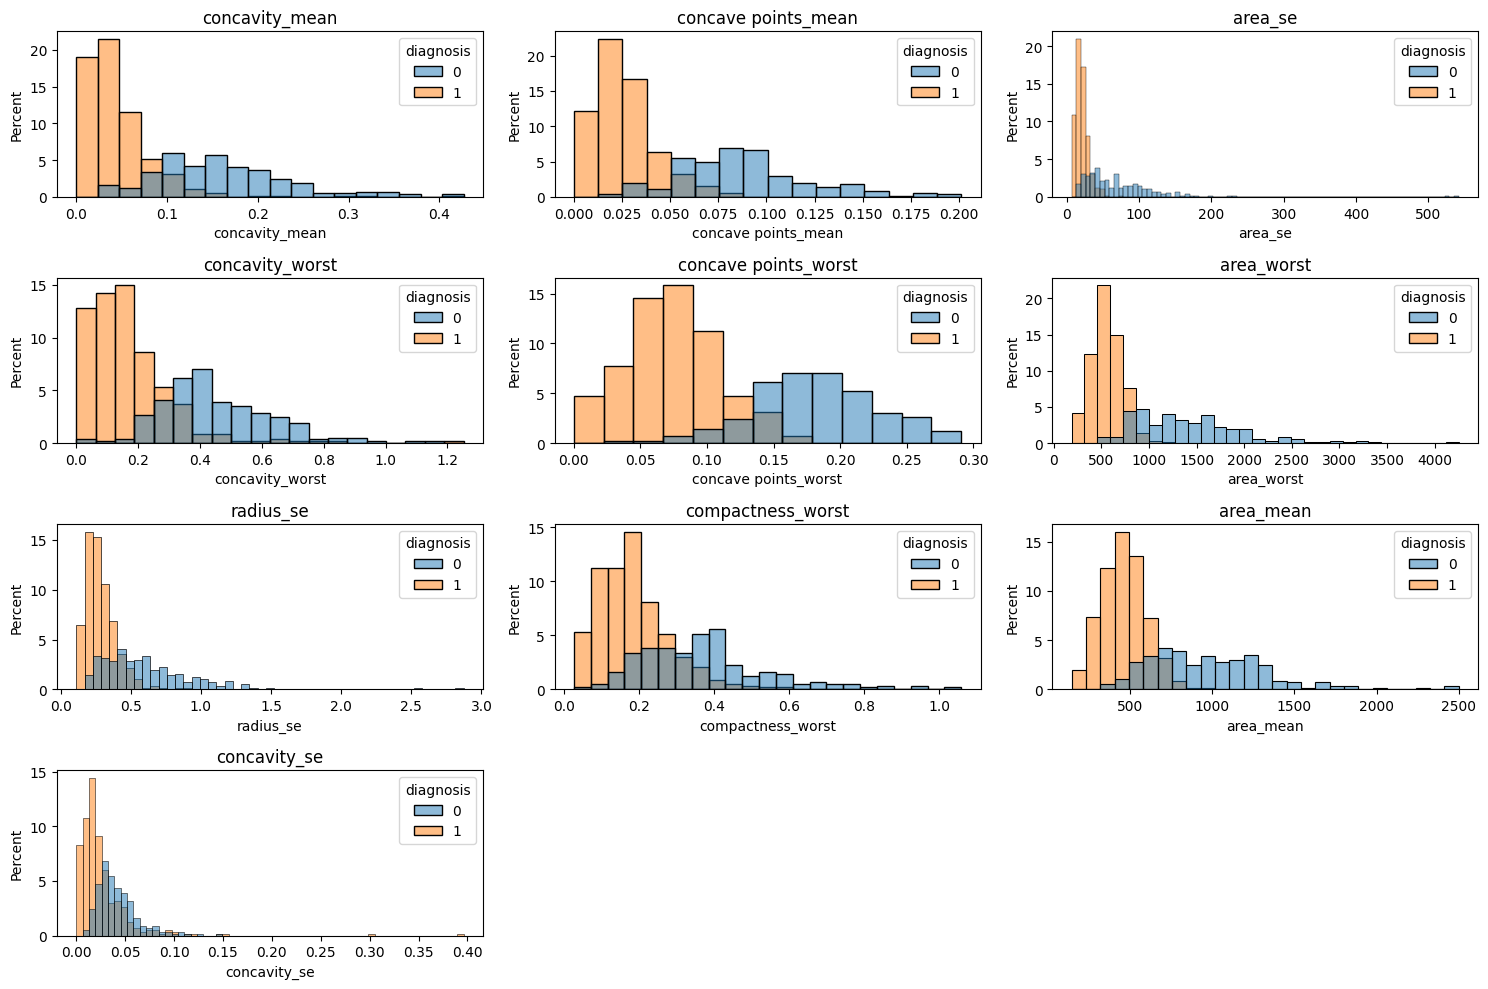

In [662]:
# смотрим 10 максимально различимых параметров
diff_field_lst = list(diff_field.iloc[:10].index)

fig, axes = plt.subplots(4, 3, figsize=(15, 10))
axes_iter = axes.flat
for field, axis in zip(diff_field_lst, axes_iter):
    sns.histplot(dataset_hosp, x = field, hue = "diagnosis",
                 element = "bars", stat = "percent", ax = axis)
    axis.set_title(field)
# удаляем незадействованные оси
for axis in axes_iter:
    fig.delaxes(axis)
# графики мы подписали, теперь нужно место для title
plt.tight_layout()
plt.show()

хорошо различимые параметры есть, это хорошо

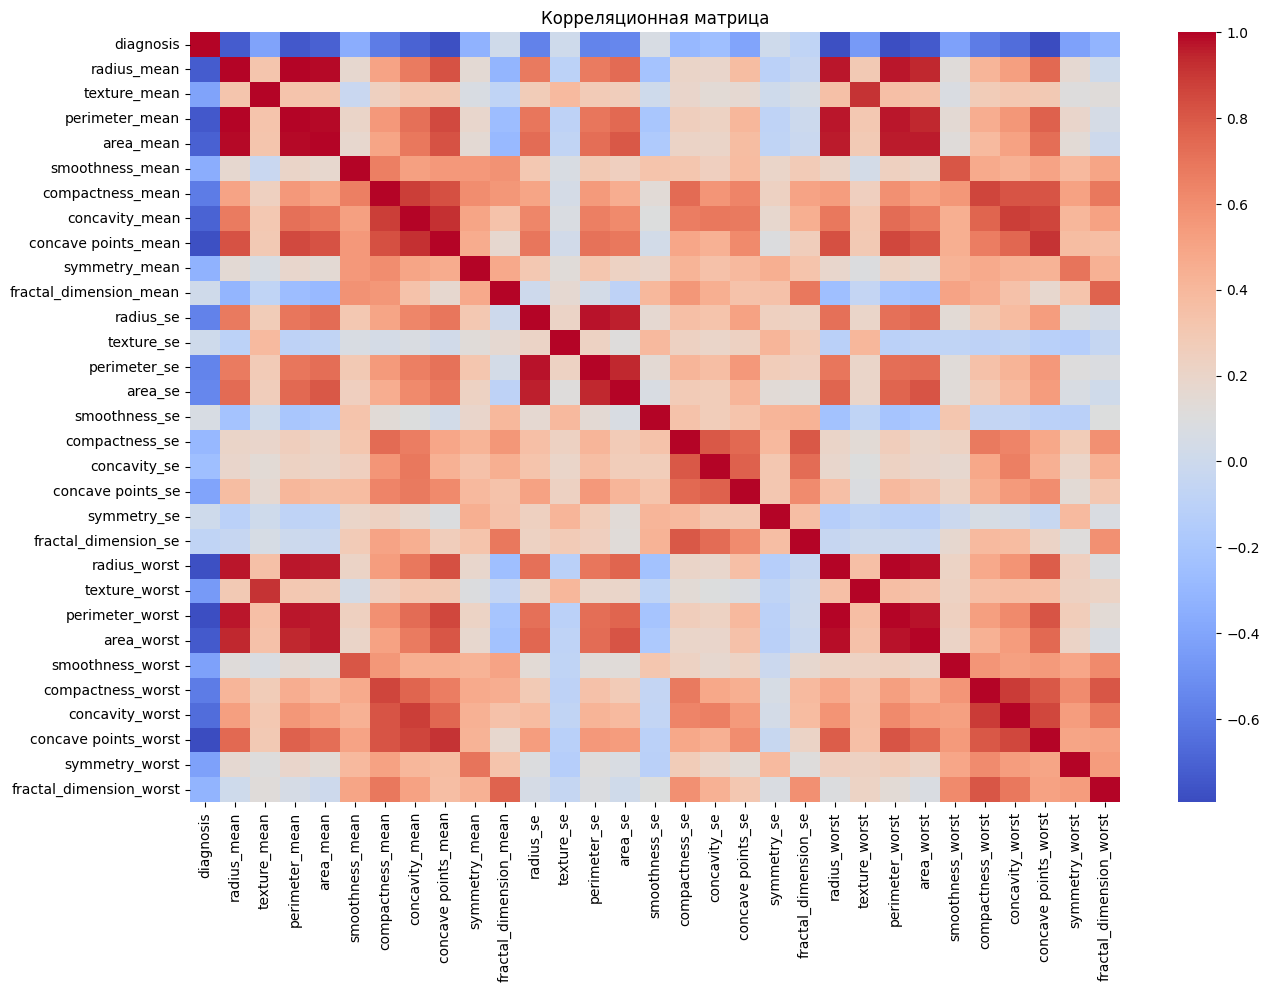

In [663]:
dataset_hosp_corr = dataset_hosp.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(dataset_hosp_corr, annot=False, cmap='coolwarm')
plt.title("Корреляционная матрица")
plt.show()

In [664]:
# готовим плоскую матрицу корреляций
corr_plane = pd.DataFrame(columns = ["relative_corr", "row", "col", "target_diff_corr"])
# исходная матрица симметричная, главная диагональ нам не нужна
# поэтому вложенный массив ограничиваем
for row in range(dataset_hosp_corr.shape[0]):
    for col in range(row + 1, dataset_hosp_corr.shape[1]):
        row_field = dataset_hosp_corr.index[row]
        col_field = dataset_hosp_corr.columns[col]

        corr_plane.loc[f"{row} - {col}"] = [abs(dataset_hosp_corr.iloc[row, col]),
                               row_field, col_field,
                               abs(dataset_hosp_corr["diagnosis"].loc[row_field] -
                                   dataset_hosp_corr["diagnosis"].loc[col_field])]
corr_plane.sort_values(by = "relative_corr", inplace = True, ascending = False)
corr_plane.head()

,relative_corr,row,col,target_diff_corr
1 - 3,0.997855,radius_mean,perimeter_mean,0.012607
21 - 23,0.993708,radius_worst,perimeter_worst,0.006460
1 - 4,0.987357,radius_mean,area_mean,0.021045
3 - 4,0.986507,perimeter_mean,area_mean,0.033652
21 - 24,0.984015,radius_worst,area_worst,0.042629


Признаки с высокой корреляцией между собой, ожидаемо имеют схожую корреляцию с целевой переменной (разница корреляций в сотых долях, иногда в тысячных).
Поэтому логично удалять не по корреляции с целевой переменной, а по различимости признака (например, среднее должно максимально отличаться).

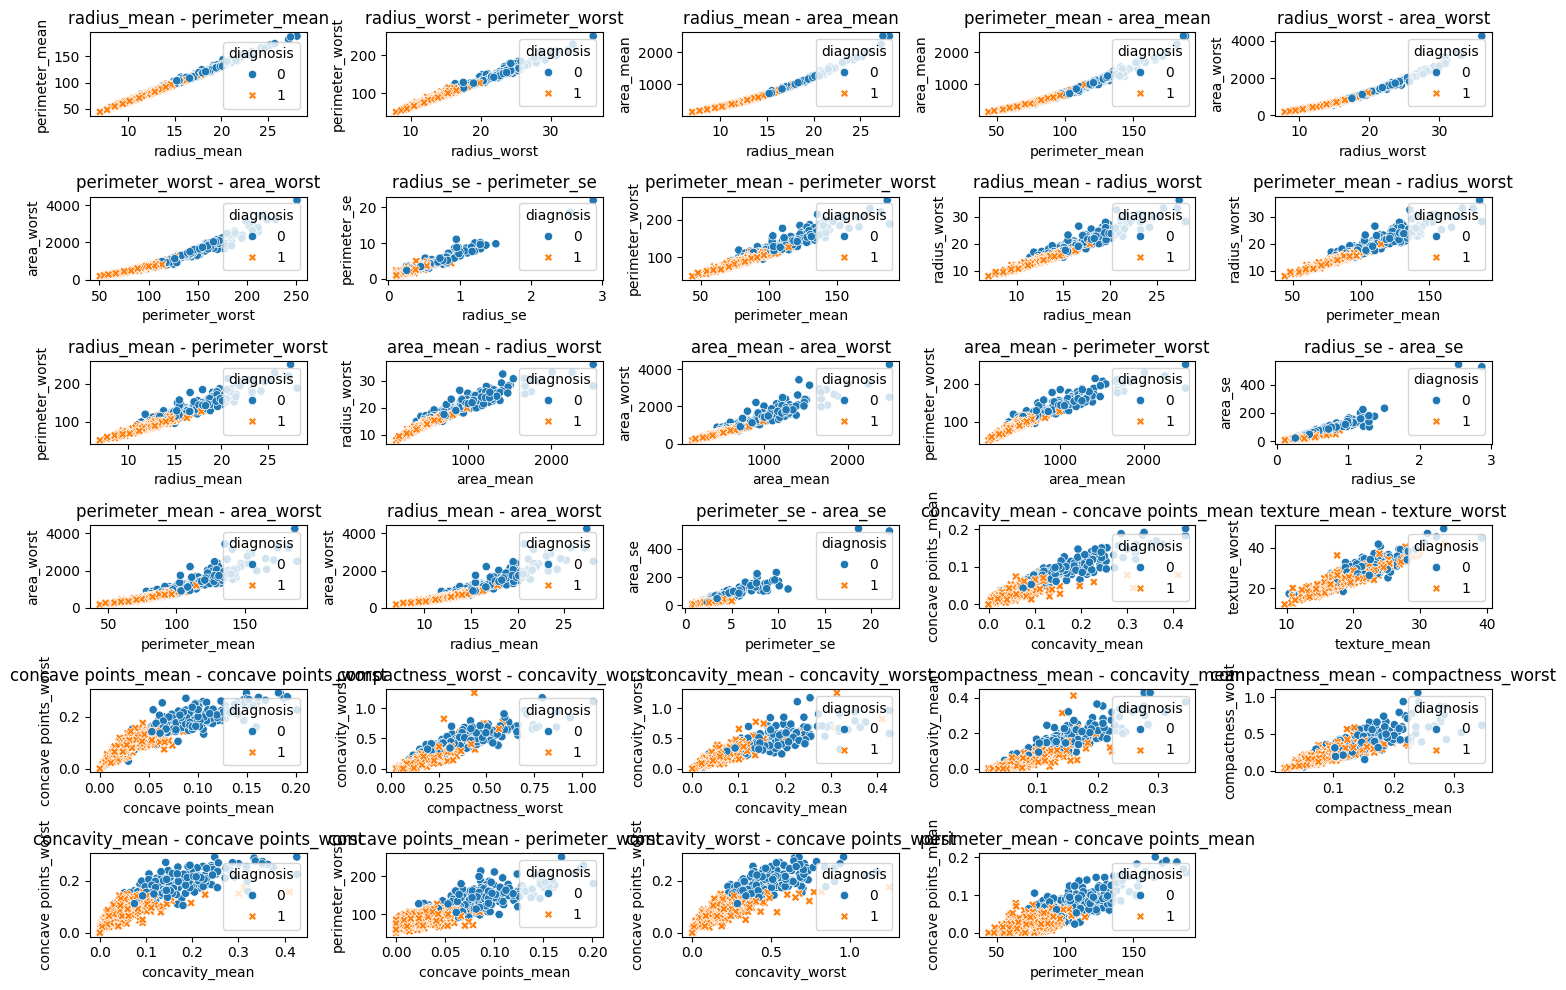

In [665]:
tangle_coll = corr_plane[corr_plane["relative_corr"] > allow_corr_max]

plt_col_count = 5
plt_row_count = 1 + int(tangle_coll.shape[0] / plt_col_count)
fig, axes = plt.subplots(plt_row_count, plt_col_count, figsize=(15, 10))

axes_iter = axes.flat
tangle_coll_iter = tangle_coll.iterrows()
for corr_row, axis in zip(tangle_coll_iter, axes_iter):
    sns.scatterplot(dataset_hosp, x = corr_row[1]["row"], y = corr_row[1]["col"], hue = "diagnosis",
                 style = "diagnosis", ax = axis)
    axis.set_title(f"{corr_row[1]["row"]} - {corr_row[1]["col"]}")
# удаляем незадействованные оси
for axis in axes_iter:
    fig.delaxes(axis)
# графики мы подписали, теперь нужно место для title
plt.tight_layout()
plt.show()
for corr_row, axis, ind in zip(tangle_coll_iter, axes_iter, range(8)):
    sns.scatterplot(dataset_hosp, x = corr_row[1]["row"], y = corr_row[1]["col"], hue = "diagnosis",
                 style = "diagnosis", ax = axis)

Зависимость линейная, либо квадратичная низких степеней (близка к линейной).
В логистической регрессии эти параметры лучше удалить, во избежание переобучения модели.

##KNeighborsClassifier

In [666]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc

In [667]:
x = dataset_hosp.drop(["diagnosis"], axis = "columns")
y = dataset_hosp["diagnosis"]
x_train, x_test, y_train, y_test = train_test_split(x, y,
    test_size = 0.3, random_state = 111, stratify = y)

# нормируем значения параметров,
# иначе при расчете расстояния параметры с большими значениями будут иметь больший вес
# (квадрат маленького числа существенно не изменит квадрат большого числа)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [668]:
knn = KNeighborsClassifier()
knn.fit(x_train_scaled, y_train)
pred = knn.predict(x_test_scaled)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        64
           1       0.96      1.00      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



In [669]:
knn = KNeighborsClassifier(n_neighbors=10)
scores = cross_val_score(knn, x, y, cv=5, scoring="accuracy")
print(scores)
print(f"mean: {scores.mean()}, std: {scores.std()}")

[0.87719298 0.93859649 0.94736842 0.95614035 0.9380531 ]
mean: 0.9314702685918336, std: 0.027933867205761444


Площадь под кривой 0.98


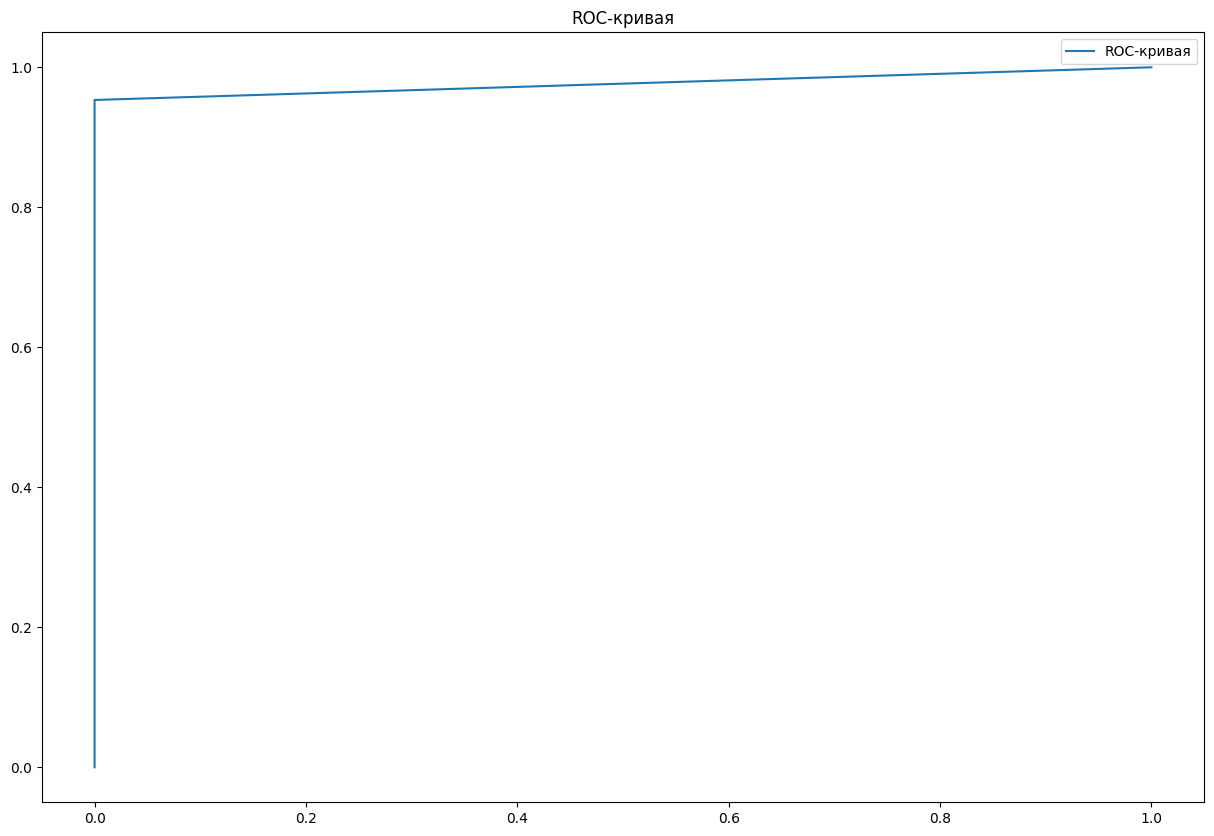

In [670]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
print(f"Площадь под кривой {auc(fpr, tpr):.2}")

plt.figure(figsize=(15, 10))
plt.plot(fpr, tpr, label = "ROC-кривая")
plt.title("ROC-кривая")
plt.legend()
plt.show()

## LogisticRegression

In [671]:
# Удаляем признаки с высокой корреляцией между собой,
# выбор делаем по различимости признака (среднее должно максимально отличаться)
columns_learn_prepare(dataset_hosp, corr_plane, diff_field)
dataset_hosp.head()

,diagnosis,radius_mean,texture_mean,smoothness_mean,compactness_mean,symmetry_mean,fractal_dimension_mean,texture_se,perimeter_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,smoothness_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0,17.99,10.38,0.11840,0.27760,0.2419,0.07871,0.9053,8.589,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,0.1622,0.2654,0.4601,0.11890
1,0,20.57,17.77,0.08474,0.07864,0.1812,0.05667,0.7339,3.398,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,0.1238,0.1860,0.2750,0.08902
2,0,19.69,21.25,0.10960,0.15990,0.2069,0.05999,0.7869,4.585,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,0.1444,0.2430,0.3613,0.08758
3,0,11.42,20.38,0.14250,0.28390,0.2597,0.09744,1.1560,3.445,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,0.2098,0.2575,0.6638,0.17300
4,0,20.29,14.34,0.10030,0.13280,0.1809,0.05883,0.7813,5.438,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,0.1374,0.1625,0.2364,0.07678


In [672]:
model = LogisticRegression()
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        64
           1       0.96      1.00      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



Площадь под кривой 0.98


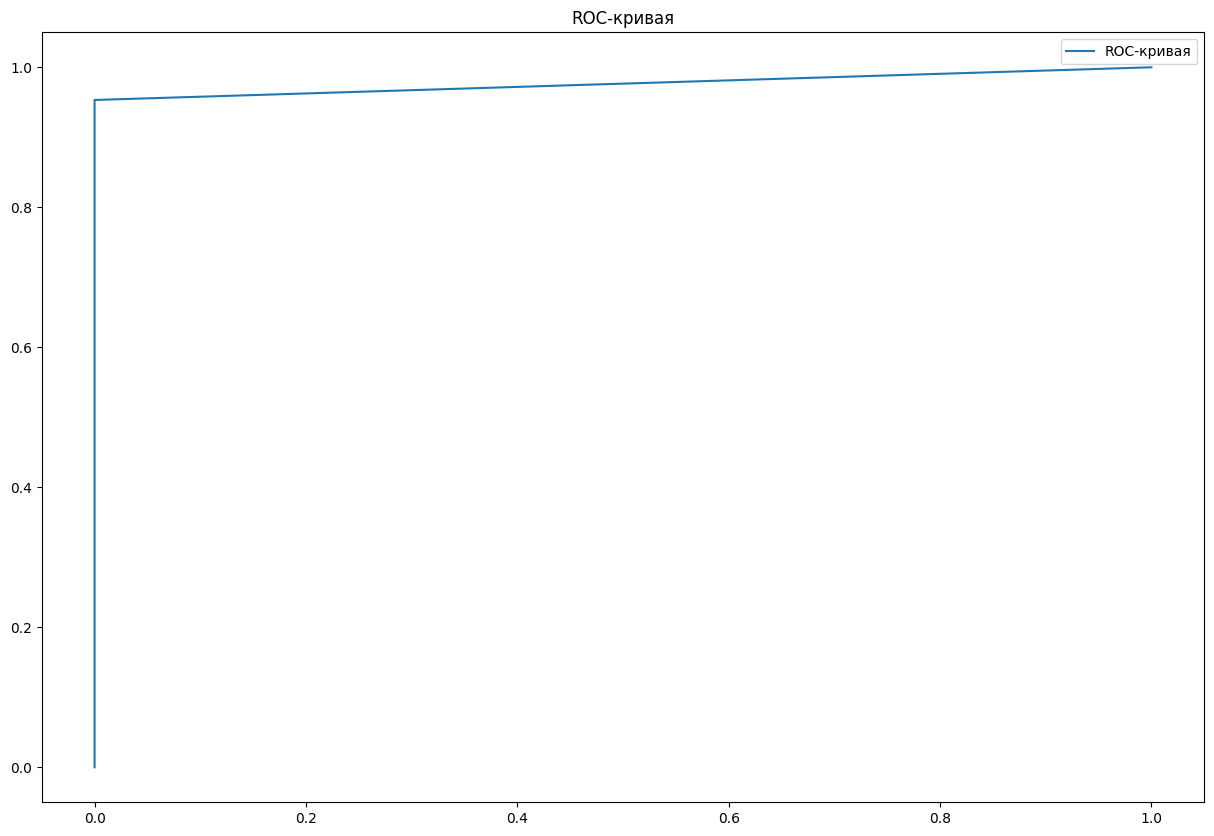

In [673]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
print(f"Площадь под кривой {auc(fpr, tpr):.2}")

plt.figure(figsize=(15, 10))
plt.plot(fpr, tpr, label = "ROC-кривая")
plt.title("ROC-кривая")
plt.legend()
plt.show()